![logo](../../../.././docs/images/Logo_Destination_Earth_Colours.png)

## Using earthkit with the Destination Earth Climate Digital Twins

This notebook introduces the core earthkit libraries and shows how to retrieve, inspect, and visualise a snapshot of Destination Earth Climate DT data using the Polytope API.

**What you will learn**
- How to build a Polytope request and pull data from the Climate DT stream
- How to explore data with `earthkit.data`
- How to make quick global and regional maps with `earthkit.plots`
- How to regrid from the native HEALPix grid to a regular latitude-longitude grid with `earthkit.geo`

## Setup

The earthkit suite is a set of focused packages that work well together but can also be used
independently.  Here we import the four we need:

| Package | Alias | Purpose |
|---------|-------|---------|
| `earthkit.data` | `ekd` | Data access, I/O, fieldlist operations |
| `earthkit.plots` | `ekp` | Cartographic and time-series visualisation |
| `earthkit.geo` | `ekg` | Regridding, spatial utilities |
| `earthkit.transforms` | `ekt` | Temporal/spatial statistics and aggregations |

We also tell xarray to propagate metadata attributes through operations (`keep_attrs=True`), which
means units and long names stay attached to arrays after arithmetic.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.geo as ekg

### Retrieving data from the Climate DT

**Key request fields**

| Field | Value | Meaning |
|-------|-------|---------|
| `activity` | `projections` | SSP scenario projections (vs. `baseline` historical runs) |
| `experiment` | `SSP3-7.0` | Middle-of-the-road high-emissions scenario |
| `model` | `IFS-NEMO` | Coupled atmosphere–ocean model |
| `stream` | `clte` | Climate hourly time-step stream |
| `param` | `151/165/166/167` | MSL pressure, 10 m U-wind, 10 m V-wind, 2 m temperature |
| `levtype` | `sfc` | Surface-level fields only |
| `resolution` | `standard` | Native model resolution (~9 km HEALPix nside=512) |

The data arrives as GRIB and is automatically parsed into a *fieldlist* — an ordered collection of
individual GRIB fields that earthkit can index, filter, and convert.

In [2]:
request = {
    'activity': 'projections',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '20260526',
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'IFS-NEMO',
    'param': '151/165/166/167',
    'realization': '1',
    'resolution': 'standard',
    'stream': 'clte',
    'time': '0100',
    'type': 'fc'
}

data = ekd.from_source(
    "polytope",
    "destination-earth",
    request,
    address="polytope.mn5.apps.dte.destination-earth.eu",
    stream=False,
).to_fieldlist()

# ls() prints a compact summary table: one row per GRIB field
data.ls()

2026-06-05 11:56:57 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-05 11:56:57 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20260526'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'param: 151/165/166/167\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0100'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-05 11:56:57 - INFO - Polytope user key found in session cache for user mavj
2026-06-05 11:56:58 - INFO - Request accepted. Please poll ./4207a01c-33a6-4993-bc44-0154947607dc for status
2026-06-05 11:56:58 - INFO - Polytope user key found in session cache for user mavj
2026-06-05 11:56:58 - INFO - Checking request status (4207a01c-33a6-4993-bc44-0154947607dc)...
20

4207a01c-33a6-4993-bc44-0154947607dc.grib:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,msl,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,0,mean_sea,None,healpix
1,10u,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,10,height_above_ground_level,None,healpix
2,10v,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,10,height_above_ground_level,None,healpix
3,2t,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,2,height_above_ground_level,None,healpix


`ekp.geo.plot` is the fastest way to see all fields at once.  It creates one panel per field and
picks sensible defaults for colour scales and projections.  Useful for a sanity check right after
retrieval.

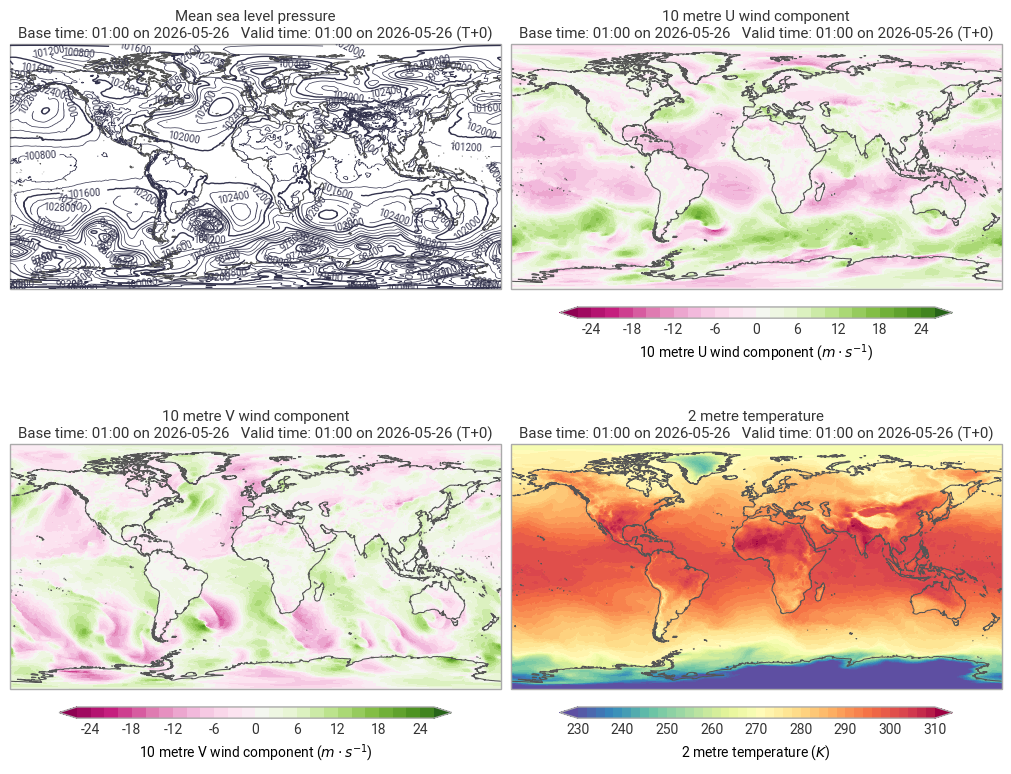

In [3]:
ekp.geo.plot(data)

The fieldlist is ordered the same way as the `param` string in the request (`151/165/166/167`),
so we can unpack it directly into named variables.

In [4]:
msl, wind_u, wind_v, t2m = data

### Visualisation

Climate DT data is stored on a **HEALPix** grid - an equal-area hierarchical tiling originally
developed for CMB cosmology. Unlike regular lat-lon grids, each cell covers the same solid angle
on the sphere, which avoids the polar over-sampling problem.

`grid_cells` renders the actual grid polygons rather than interpolating to pixels, so you can see
the cell shapes directly. `style="auto"` picks the colour scale automatically from the field
metadata. `.borders()` adds country borders as a layer on top.

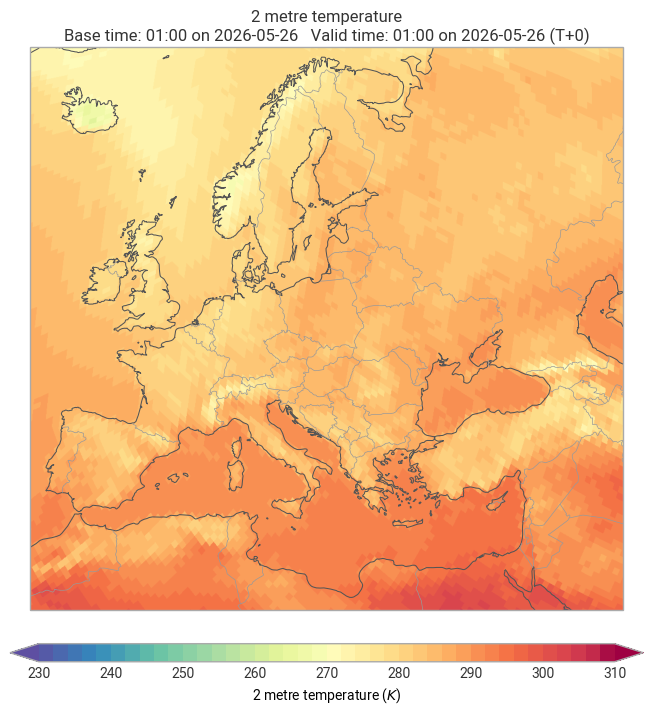

In [5]:
ekp.geo.grid_cells(t2m, domain="Europe", style="auto").borders()

`ekp.geo.plot` also accepts multiple fields.  Passing `t2m` and `msl` together renders temperature
as a filled background and mean-sea-level pressure as contours — earthkit infers the most useful
combination automatically.

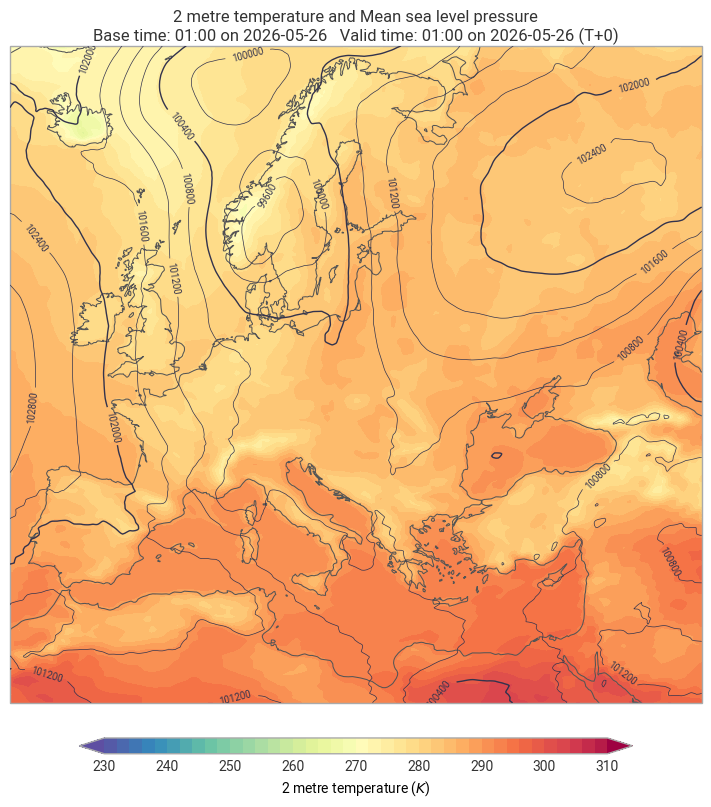

In [6]:
ekp.geo.plot(t2m, msl, domain="Europe")

The `ekp.Map` class gives you fine-grained control over every layer.  The recipe below shows the
typical workflow:

1. Create a `Map` for a named domain
2. Add filled colour (`chart.plot`) for the primary variable, converting units on the fly
3. Add pressure contours on top
4. Add a wind barb / quiver layer
5. Decorate with coastlines, borders, gridlines, legend, and an auto-generated title

Unit conversion (K → °C, Pa → hPa) is handled by earthkit so you don't need to transform the
array yourself.

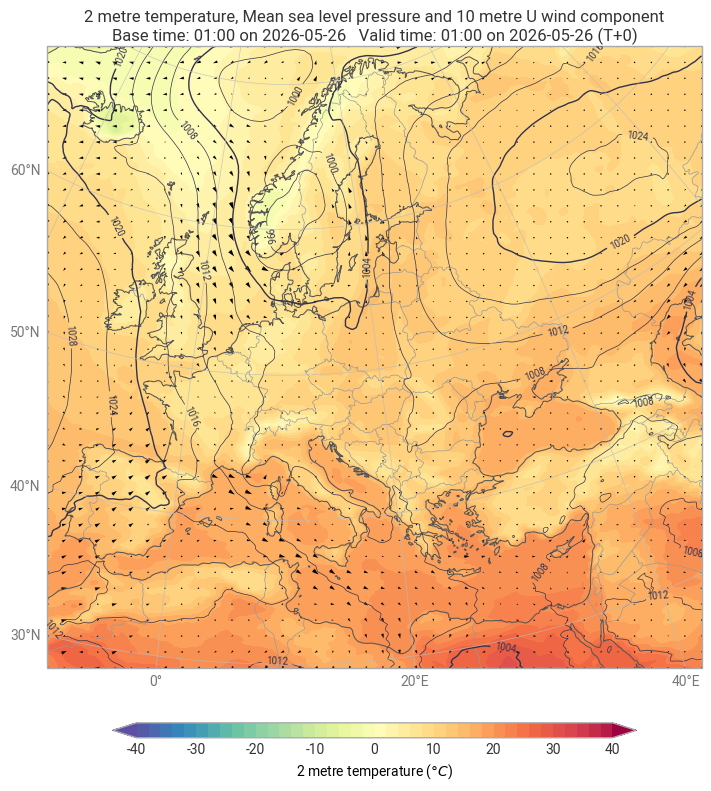

In [7]:
chart = ekp.Map(domain="Europe")

chart.plot(t2m, units="celsius")
chart.plot(msl, units="hPa")
chart.legend()

chart.quiver(wind_u, wind_v)

chart.borders()
chart.coastlines()
chart.gridlines()

chart.title()

chart.show()

### Regridding

Many downstream tools (statistical packages, other models, simple array arithmetic) expect data on
a regular lat-lon grid.  `ekg.regrid` re-interpolates a field to any target resolution.

The weight matrix for the interpolation is computed once and cached to disk, so subsequent calls
with the same source/target combination are fast.  Here we target 0.5 ° × 0.5 °.

In [8]:
regular_ll = ekg.regrid(t2m, [0.5, 0.5])
regular_ll

number_of_values,259920
array_type,ndarray
array_dtype,float64
variable,2t
standard_name,air_temperature
long_name,2 metre temperature
units,kelvin
chem_variable,None
valid_datetime,2026-05-26 01:00:00
base_datetime,2026-05-26 01:00:00
step,0:00:00


`ekp.Figure` lets you arrange multiple map panels in a grid layout.  This comparison panel shows
the same temperature field on both grids over France and Spain, making the hexagonal HEALPix cells
and the rectangular lat-lon cells visually obvious at this zoom level.

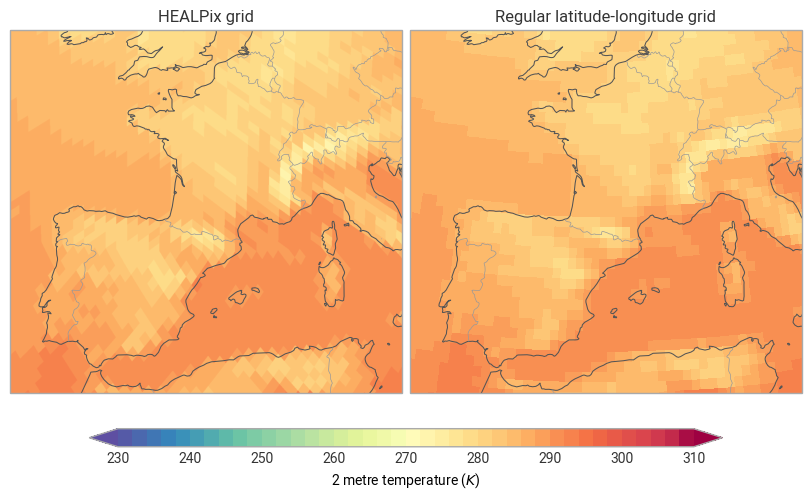

In [9]:
fig = ekp.Figure(domain=["France", "Spain"], rows=1, columns=2)

healpix_plot = fig.add_map()
healpix_plot.grid_cells(t2m, style="auto")
healpix_plot.title("HEALPix grid")

regular_ll_plot = fig.add_map()
regular_ll_plot.grid_cells(regular_ll, style="auto")
regular_ll_plot.title("Regular latitude-longitude grid")

fig.coastlines()
fig.borders()
fig.legend()

fig.show()

### Exercises

1. Try regridding the same 2m temperature data to a higher (e.g. 0.1 degrees) or lower (e.g. 1 degrees) resolution, and plot it side-by-side with the original HEALPix grid.

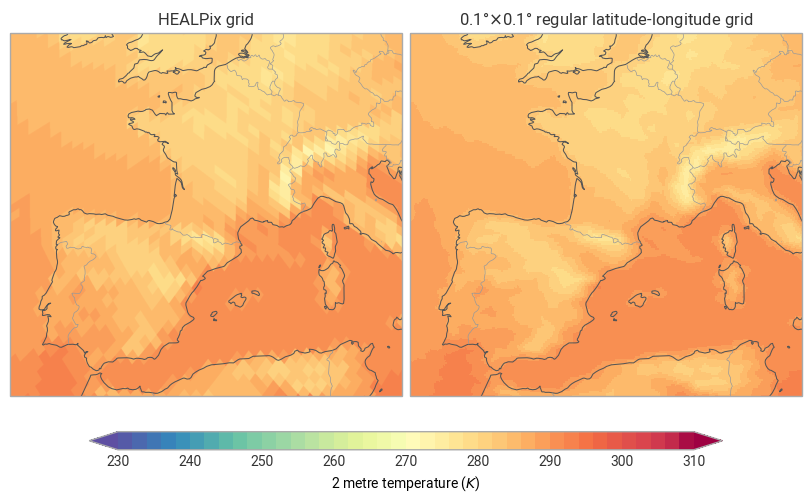

In [10]:
t2m_0p1 = ekg.regrid(t2m, [0.1, 0.1])

fig = ekp.Figure(domain=["France", "Spain"], rows=1, columns=2)

healpix_plot = fig.add_map()
healpix_plot.grid_cells(t2m, style="auto")
healpix_plot.title("HEALPix grid")

regular_ll_plot = fig.add_map()
regular_ll_plot.grid_cells(t2m_0p1, style="auto")
regular_ll_plot.title(r"0.1°$\times$0.1° regular latitude-longitude grid")

fig.coastlines()
fig.borders()
fig.legend()

fig.show()

---
### Summary

In this notebook you:
- Retrieved a single time-step of four surface fields from the Climate DT projections stream
- Inspected the fieldlist and visualised the data at global and regional scales
- Built a fully annotated, multi-layer European chart with wind vectors
- Regridded the native HEALPix data to a regular 0.5 ° grid and compared the two representations

**Next:** `02-earthkit-analysis.ipynb` extends these ideas to a full multi-decadal dataset,
introduces temporal and spatial statistics, and shows how to compare Climate DT output against
ERA5 reanalysis.